## Goal: To check if the model initially designed for Dakar can be used for other locations

### Location considered: Bamako, Selibaby

In [225]:
import pandas as pd                                                                     # type: ignore
import matplotlib.pyplot as plt                                                         # type: ignore
import seaborn as sns                                                                   # type: ignore
import numpy as np                                                                      # type: ignore
from  sklearn import metrics                                                            # type: ignore
from sklearn.preprocessing import StandardScaler                                        # type: ignore
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss                  # type: ignore
from sklearn.metrics import average_precision_score                                     # type: ignore
import tensorflow as tf                                                                 # type: ignore
from tensorflow.keras.initializers import he_normal                                     # type: ignore
from sklearn.model_selection import train_test_split                                    # type: ignore
import matplotlib as mpl                                                                # type: ignore
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
mpl.rcParams['figure.figsize'] = (9, 7)
from joblib import dump, load                                                           # type: ignore
import sys
sys.path.insert(1, "/home/mendrika/mendrika-phd/codes/nflics")
import nflics  

### Importing dataset

In [226]:
train_data_Bamako = pd.read_csv("./train-data-Bamako.csv", index_col=False)
train_data_Dakar = pd.read_csv("./train-data-Dakar.csv", index_col=False)
train_data_Selibaby = pd.read_csv("./train-data-Selibaby.csv", index_col=False)

test_data_Bamako = pd.read_csv("./test-data-Bamako.csv", index_col=False)
test_data_Dakar = pd.read_csv("./test-data-Dakar.csv", index_col=False)
test_data_Selibaby = pd.read_csv("./test-data-Selibaby.csv", index_col=False)

In [227]:
# considering all data from 2004 to 2022
#test_data_Bamako = pd.concat([train_data_Bamako, test_data_Bamako])
#test_data_Selibaby = pd.concat([train_data_Selibaby, test_data_Selibaby])

### Check if the data have outliers

In [228]:
variable = "lon"
for i in range(5):
    print(np.min(test_data_Bamako[f"{variable}{i+1}"]), np.max(test_data_Bamako[f"{variable}{i+1}"]))

-8.99 0.99
-8.99 0.99
-8.99 6.9971
-8.99 6.9971
-8.99 6.9971


#### Choosing field to include in the data

In [229]:
lead_time = 3

In [230]:
def get_field(location, lead_time):
    target_index = f"Cb_{location}_t{lead_time}"    
    t0 = "year,month,day,hour,minute,"
    location = ""
    wavelet_power = ""
    storm_size = ""
    distance = ""
    for i in range(1,6):
        location += f"lat{i},lon{i},"
        wavelet_power += f"wp{i},"
        distance += f"ds{i},"
        storm_size += f"size{i},"
    features = t0 + location + wavelet_power + storm_size + distance
    field =  features + target_index    
    return field.split(',')

In [231]:
test_data_Bamako = test_data_Bamako[get_field("Bamako", lead_time=lead_time)]
test_data_Dakar = test_data_Dakar[get_field("Dakar", lead_time=lead_time)]
test_data_Selibaby = test_data_Selibaby[get_field("Selibaby", lead_time=lead_time)]

### Transforming latitude and longitude to relative latitude and relative longitude

### Transforming to relative latitude and longitudes

In [232]:
def transform_to_relative_latlton(df, location_lat, location_lon):
    for i in range(5):
        df[f"lat{i+1}"] = df[f"lat{i+1}"] - location_lat
        df[f"lon{i+1}"] = df[f"lon{i+1}"] - location_lon
    return df

In [233]:
Bamako_lat, Bamako_lon = 12.6392, -8.0029
Dakar_lat, Dakar_lon = 14.716677, -17.467686
Selibaby_lat, Selibaby_lon = 15.1506, -12.1804

In [234]:
test_data_Bamako = transform_to_relative_latlton(test_data_Bamako, Bamako_lat, Bamako_lon)
test_data_Dakar = transform_to_relative_latlton(test_data_Dakar, Dakar_lat, Dakar_lon)
test_data_Selibaby = transform_to_relative_latlton(test_data_Selibaby, Selibaby_lat, Selibaby_lon)

### Exploratory data analysis

In [235]:
def log_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i > 0:
                transformed.append(np.log(i))
            else:
                transformed.append(np.log(i+1e-8))    
        df_copy[key] = transformed
    return df_copy

In [236]:
def sqrt_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i >= 0:
                transformed.append(np.sqrt(i)) 
        df_copy[key] = transformed
    return df_copy

In [237]:
t0 = "year,month,day,hour,minute,"
location = ""
wavelet_power = ""
storm_size = ""
distance = ""
for i in range(1,6):
    location += f"lat{i},lon{i},"
    wavelet_power += f"wp{i},"
    distance += f"ds{i},"
    storm_size += f"size{i},"

to_scale = wavelet_power + storm_size + distance

In [238]:
def prepare_for_test(df):
    df = log_transform(df, to_scale.split(',')[:-1])
    df = sqrt_transform(df, t0.split(',')[:-1])
    return df

In [239]:
test_data_Bamako = prepare_for_test(test_data_Bamako)
test_data_Dakar = prepare_for_test(test_data_Dakar)
test_data_Selibaby = prepare_for_test(test_data_Selibaby)

### Splitting the data  into training and testing before oversampling the training set

### Normalising the features

In [240]:
test_data_Selibaby

,year,month,day,hour,minute,lat1,lon1,lat2,lon2,lat3,...,size2,size3,size4,size5,ds1,ds2,ds3,ds4,ds5,Cb_Selibaby_t3
0,44.944410,2.44949,1.000000,4.000000,5.477226,-3.6906,-0.5796,2.4094,5.1704,0.0000,...,7.661527,-18.420681,-18.420681,-18.420681,4.890199,5.311628,6.253829,6.253829,6.253829,0.0
1,44.944410,2.44949,1.000000,4.000000,6.708204,-3.6506,-0.5796,2.5494,5.1304,0.0000,...,8.022897,-18.420681,-18.420681,-18.420681,4.875426,5.313403,6.253829,6.253829,6.253829,0.0
2,44.944410,2.44949,1.000000,4.123106,3.872983,1.5594,5.1704,-2.9306,-0.4396,-4.9506,...,9.328123,9.853509,5.926926,-18.420681,4.657003,4.827914,5.249232,5.869664,6.253829,0.0
3,44.944410,2.44949,1.000000,4.123106,5.477226,-4.8206,8.7604,1.6494,5.2104,-3.3806,...,9.487972,9.137770,9.137770,-18.420681,4.617099,4.796204,5.263881,5.850275,6.253829,0.0
4,44.944410,2.44949,1.000000,4.123106,6.708204,-4.8606,8.7604,1.6994,5.1704,-2.5706,...,9.510445,9.536041,7.891705,-18.420681,4.552508,4.788075,5.262172,5.851685,6.253829,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19167,44.966654,3.00000,5.477226,4.000000,6.708204,1.3394,1.0804,-2.8406,3.7304,0.2594,...,8.444622,10.072175,10.072175,9.192685,4.122608,5.067897,5.417300,5.460011,5.709831,0.0
19168,44.966654,3.00000,5.477226,4.123106,0.000000,-3.7406,0.3204,1.3394,1.0404,-2.8406,...,6.907755,7.661527,7.562681,10.255024,4.112021,4.875655,5.062911,5.306682,5.431492,0.0
19169,44.966654,3.00000,5.477226,4.123106,3.872983,-2.8406,3.6404,-3.6906,0.2304,1.5594,...,7.853605,8.912608,8.167636,10.105407,4.177306,4.859812,5.052992,5.289983,5.393673,0.0
19170,44.966654,3.00000,5.477226,4.123106,5.477226,0.9794,0.9004,-3.6506,0.0504,-2.8406,...,9.413281,8.181720,8.925986,8.594154,3.858200,4.153085,4.853123,5.047995,5.330543,0.0


In [241]:
x_test_Bamako = test_data_Bamako.drop([f"Cb_Bamako_t{lead_time}"], axis=1).to_numpy()
y_test_Bamako = test_data_Bamako[f"Cb_Bamako_t{lead_time}"]

x_test_Dakar = test_data_Dakar.drop([f"Cb_Dakar_t{lead_time}"], axis=1).to_numpy()
y_test_Dakar = test_data_Dakar[f"Cb_Dakar_t{lead_time}"]

x_test_Selibaby = test_data_Selibaby.drop([f"Cb_Selibaby_t{lead_time}"], axis=1).to_numpy()
y_test_Selibaby = test_data_Selibaby[f"Cb_Selibaby_t{lead_time}"]

In [242]:
scaler = load(f'Global-t{lead_time}.bin')

In [243]:
std_x_test_Bamako = scaler.transform(x_test_Bamako)
std_x_test_Dakar = scaler.transform(x_test_Dakar)
std_x_test_Selibaby = scaler.transform(x_test_Selibaby)

### Importing the model

In [244]:
model = tf.keras.models.load_model(f'/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/Global-t{lead_time}.keras')
model_t1 = tf.keras.models.load_model(f'/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/Global-t1.keras')
model_t3 = tf.keras.models.load_model(f'/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/Global-t3.keras')
model_t6 = tf.keras.models.load_model(f'/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/Global-t6.keras')

In [245]:
def class_prediction(model, x, y):
    y_hat = model.predict(x)      
    bs = brier_score_loss(y, y_hat)    
    auc = roc_auc_score(y, y_hat)
    return y_hat, auc, bs

In [246]:
def plot_cm(y, y_hat, classification_threshold):
    # compute the contingency table    
    y_hat_class = y_hat >= classification_threshold
    cm = metrics.confusion_matrix(y, y_hat_class)
    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, linewidths=.5, square = True, cmap = 'Blues_r', cbar=None, fmt='g')
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    plt.show()

### Performance on testing data

In [247]:
def cutoff_youdens_j(fpr, tpr, thresholds):
    j_scores = tpr-fpr
    j_ordered = sorted(zip(j_scores, thresholds))
    return j_ordered[-1][1]

 66/549 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

549/549 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


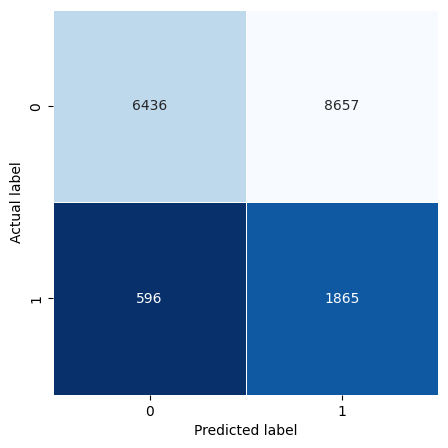

In [248]:
place = "Bamako"

if place == "Selibaby":
    std_x_test = std_x_test_Selibaby
    y_test = y_test_Selibaby
elif place == "Bamako":
    std_x_test = std_x_test_Bamako
    y_test = y_test_Bamako
else:
    std_x_test = std_x_test_Dakar
    y_test = y_test_Dakar

y_hat_test, auc_test, bs_test = class_prediction(model, std_x_test, y_test)
classification_threshold = cutoff_youdens_j(*roc_curve(y_test, y_hat_test))
plot_cm(y_test, y_hat_test, classification_threshold=classification_threshold)

In [249]:
def reliability_curve(y, y_pred, bin_size=0.1, count_pred_per_bin=100):
  y = np.array(y)
  y_pred = np.array(y_pred)
  bins = np.arange(0, 1+bin_size, bin_size)
  bin_centers = [(b1 + b2) / 2 for b1, b2 in zip(bins[:-1], bins[1:])]
  prop_positive = []
  bin_center_ax = []
  no_pred_per_bin = []
  for b1, b2, bc in zip(bins[:-1], bins[1:], bin_centers):
    in_bin = np.logical_and(y_pred >= b1, y_pred < b2)
    no_predictions_per_bin = np.sum(in_bin)
    no_positive_per_bin = np.sum(y[in_bin])    
    if no_predictions_per_bin > count_pred_per_bin:
      prop_pos = round(no_positive_per_bin/no_predictions_per_bin, 3)
      prop_positive.append(prop_pos)
      bin_center_ax.append(round(bc, 3))
      no_pred_per_bin.append(no_predictions_per_bin)
    else:
      continue
  return bin_center_ax, prop_positive, no_pred_per_bin

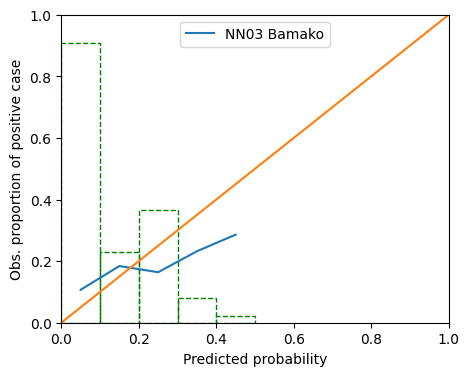

In [250]:
prob_pred, prob_true, no_pred_per_bin = reliability_curve(y_test, y_hat_test.flatten())
plt.figure(figsize=(5,4))
plt.plot(prob_pred, prob_true, label=f"NN0{lead_time} {place}")    
    
plt.xlabel("Predicted probability")
plt.ylabel("Obs. proportion of positive case")

no_pred_per_bin = [i/(1.1*np.max(no_pred_per_bin)) for i in no_pred_per_bin]
plt.plot(np.arange(0,1.2,0.2), np.arange(0,1.2,0.2))
plt.bar(prob_pred, no_pred_per_bin, width=0.1, linestyle="--", fill=False, edgecolor="green")

plt.xlim(0,1)
plt.ylim(0,1)
plt.legend(loc='upper center')
plt.show()

In [251]:
def plot_roc(name, labels, predictions, **kwargs):
  fp, tp, _ = metrics.roc_curve(labels, predictions)
  plt.plot(100*fp, 100*tp, label=name, linewidth=2, **kwargs)
  plt.xlabel('False alarm [%]')
  plt.ylabel('Hit [%]')
  plt.xlim([0,100])
  plt.ylim([0,100])
  plt.grid(True)
  ax = plt.gca()
  ax.set_aspect('equal')

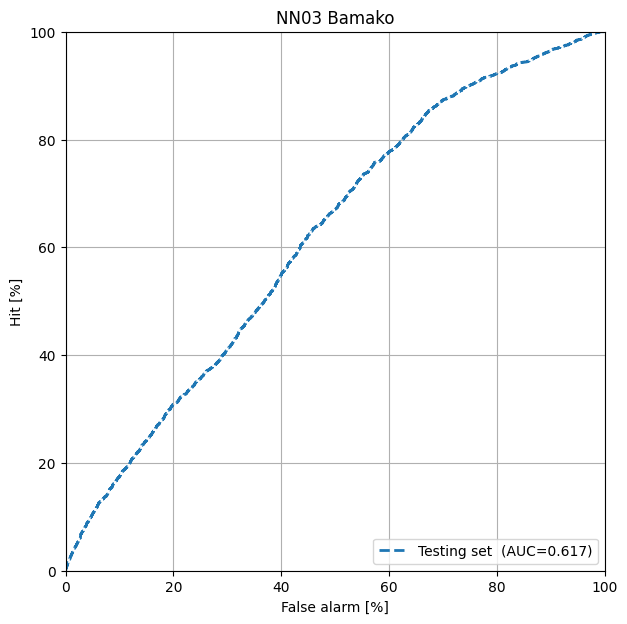

In [252]:
plot_roc(f"Testing set  (AUC={auc_test:.3f})", y_test, y_hat_test, color=colors[0], linestyle='--')
plt.title(f"NN0{lead_time} {place}")
plt.legend(loc='lower right');